In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

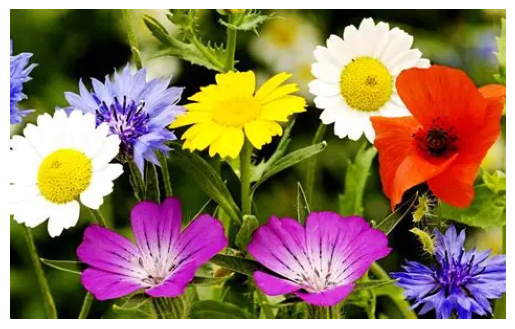

In [2]:
img = cv2.imread("flowers.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [3]:
def rgb_to_hsv(img):
    img = img / 255.0
    R,G,B = img[:,:,0], img[:,:,1], img[:,:,2]

    M = np.max(img, axis=2)
    m = np.min(img, axis=2)
    C = M - m

    H = np.zeros_like(M)
    mask = C != 0
    idx = (M == R) & mask
    H[idx] = ((G[idx] - B[idx]) / C[idx]) % 6
    idx = (M == G) & mask
    H[idx] = (B[idx] - R[idx]) / C[idx] + 2
    idx = (M == B) & mask
    H[idx] = (R[idx] - G[idx]) / C[idx] + 4
    H = H / 6

    S = np.zeros_like(M)
    S[M != 0] = C[M != 0] / M[M != 0]

    V = M

    hsv = np.stack([H,S,V], axis=2)

    return hsv

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

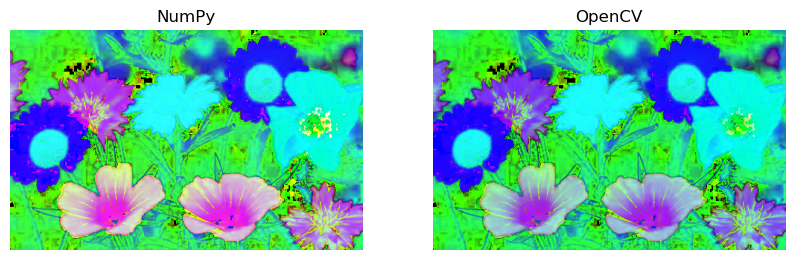

In [4]:
numpy = rgb_to_hsv(img)
opencv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy)
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv)
plt.title("OpenCV")
plt.axis("off")

In [5]:
def rgb_to_hls(img):
    img = img / 255.0
    R,G,B = img[:,:,0], img[:,:,1], img[:,:,2]

    M = np.max(img, axis=2)
    m = np.min(img, axis=2)
    C = M - m

    H = np.zeros_like(M)
    mask = C != 0
    idx = (M == R) & mask
    H[idx] = ((G[idx] - B[idx]) / C[idx]) % 6
    idx = (M == G) & mask
    H[idx] = (B[idx] - R[idx]) / C[idx] + 2
    idx = (M == B) & mask
    H[idx] = (R[idx] - G[idx]) / C[idx] + 4
    H = H / 6

    L = (M + m) / 2
    
    S = np.zeros_like(M)
    S[mask] = C[mask] / (1 - np.abs(2*L[mask]-1))

    return np.stack([H,L,S], axis=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000000000007].


(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

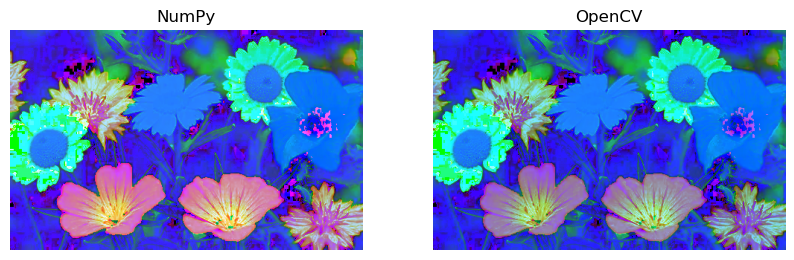

In [6]:
numpy = rgb_to_hls(img)
opencv = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy)
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv)
plt.title("OpenCV")
plt.axis("off")

In [7]:
def blend(img1, img2, a, b, g):
    result = a * img1.astype(np.float32) + b * img2.astype(np.float32) + g
    result = np.clip(result,0,255)
    return result.astype(np.uint8)

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

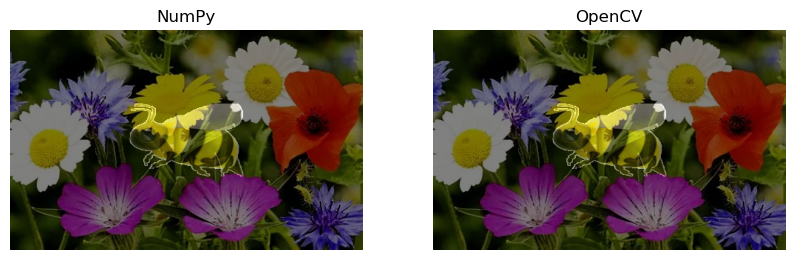

In [8]:
img2 = cv2.imread("bee.png")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2 = cv2.resize(img2, (img.shape[1], img.shape[0]))

numpy = blend(img, img2, 0.5, 0.5, 0)
opencv = cv2.addWeighted(src1=img, alpha=0.5, src2=img2, beta=0.5, gamma=0)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy)
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv)
plt.title("OpenCV")
plt.axis("off")

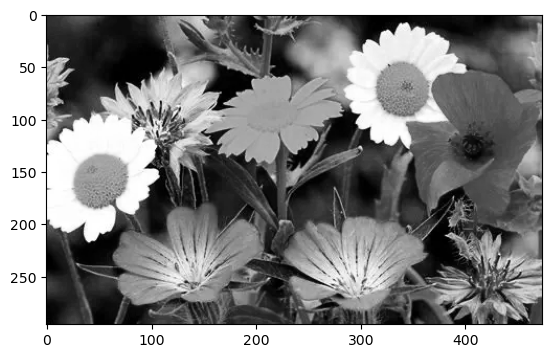

In [9]:
gray = np.mean(img, axis=2).astype(np.uint8)
plt.imshow(gray, cmap="gray")

In [10]:
def binary(img, t):
    res = np.zeros_like(img)
    res[img > t] = 255
    return res

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

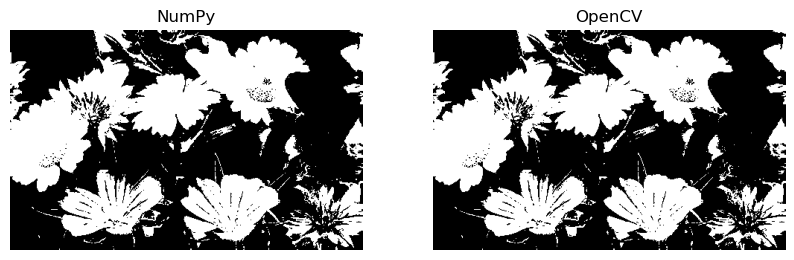

In [11]:
numpy = binary(gray, 120)
_, opencv = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

In [12]:
def binary_inv(img, t):
    res = np.zeros_like(img)
    res[img <= t] = 255
    return res

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

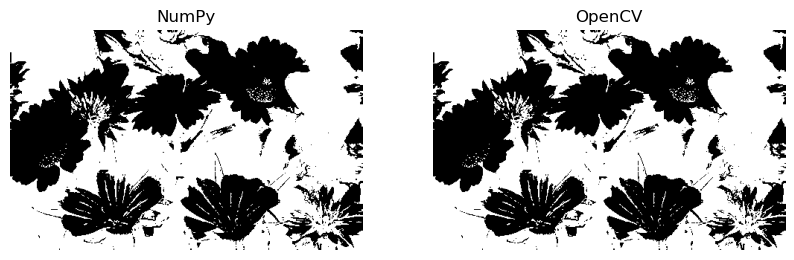

In [13]:
numpy = binary_inv(gray, 120)
_, opencv = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

In [14]:
def tozero(img, t):
    res = img.copy()
    res[img < t] = 0
    return res

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

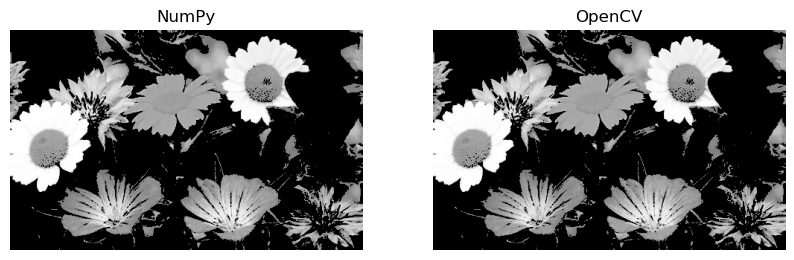

In [15]:
numpy = tozero(gray, 120)
_, opencv = cv2.threshold(gray, 120, 255, cv2.THRESH_TOZERO)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

In [16]:
def tozero_inv(img, t):
    res = img.copy()
    res[img >= t] = 0
    return res

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

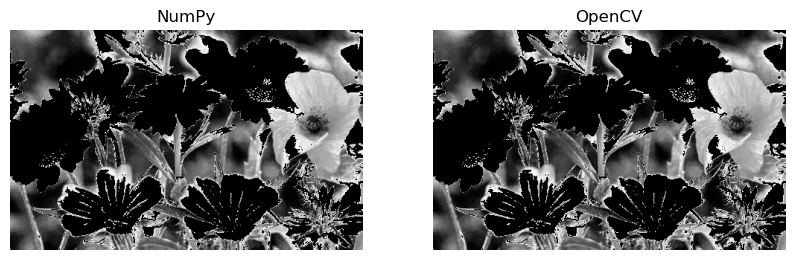

In [17]:
numpy = tozero_inv(gray, 120)
_, opencv = cv2.threshold(gray, 120, 255, cv2.THRESH_TOZERO_INV)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

In [18]:
def truncated(img, t):
    res = img.copy()
    res[img > t] = t
    return res

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

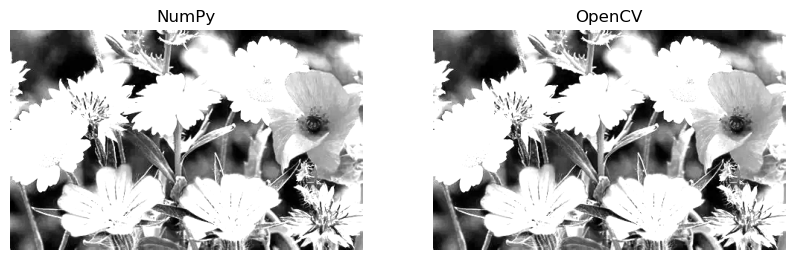

In [19]:
numpy = truncated(gray, 120)
_, opencv = cv2.threshold(gray, 120, 255, cv2.THRESH_TRUNC)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

In [20]:
def gaussian_kernel(size, sigma):
    ax = np.arange(-size//2, size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

In [21]:
def apply_filter(img, kernel):
    h,w = img.shape
    k = kernel.shape[0]

    pad = k//2
    padded = np.pad(img, pad, mode='edge')

    result = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            result[i,j] = np.sum(region * kernel)

    return result

In [22]:
def adaptive_gaussian_threshold(img, n, sigma, C, max_value=255):
    kernel = gaussian_kernel(n, sigma)
    wa = apply_filter(img, kernel)
    
    T = wa - C
    dst = np.where(img > T, max_value, 0)
    return dst.astype(np.uint8)

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

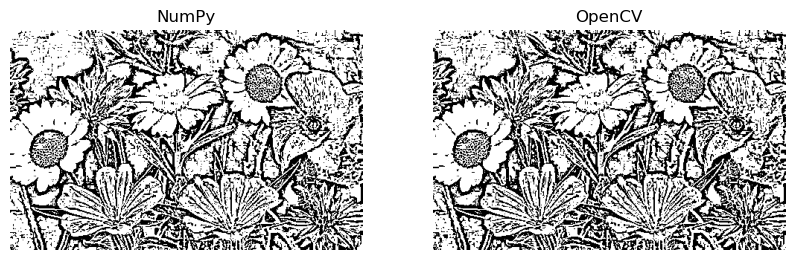

In [23]:
numpy = adaptive_gaussian_threshold(gray, 11, 2, 2)
opencv = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

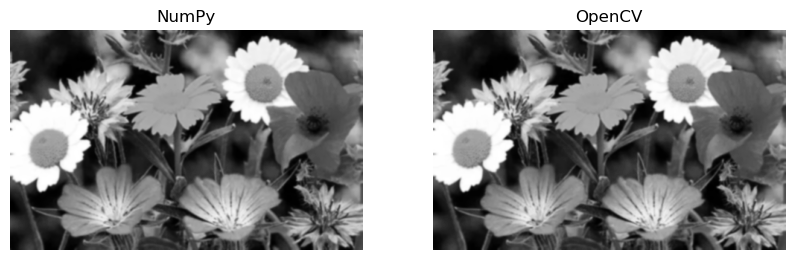

In [24]:
kernel = gaussian_kernel(5,1)
numpy = apply_filter(gray, kernel)

opencv = cv2.GaussianBlur(gray,(5,5),1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

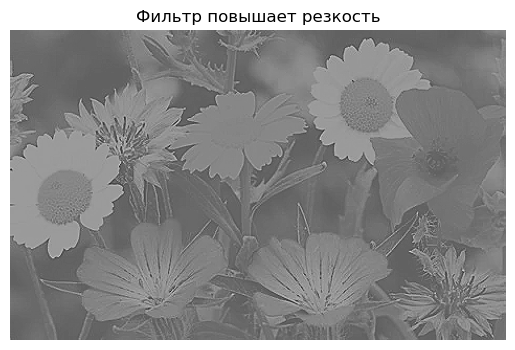

In [25]:
kernel = np.array([
[0,-1,0],
[-1,5,-1],
[0,-1,0]
])
numpy = apply_filter(gray, kernel)
plt.imshow(numpy, cmap="gray")
plt.title("Фильтр повышает резкость")
plt.axis("off")

In [26]:
def median_blur(img, k=3):
    pad = k//2
    padded = np.pad(img, pad, mode="edge")

    h,w = img.shape
    result = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            result[i,j] = np.median(region)

    return result

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

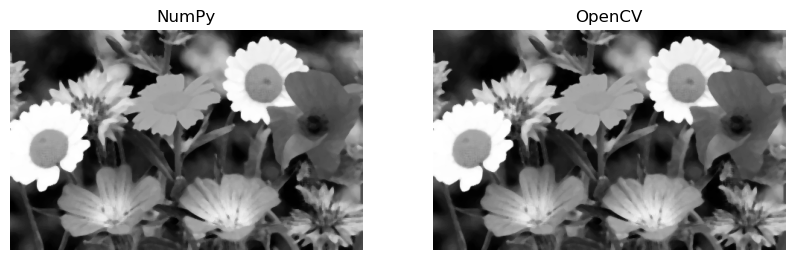

In [27]:
numpy = median_blur(gray, 5)
opencv = cv2.medianBlur(gray, 5)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(numpy, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

(np.float64(-0.5), np.float64(473.5), np.float64(295.5), np.float64(-0.5))

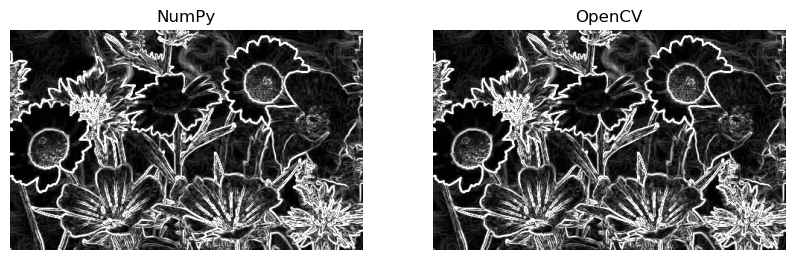

In [28]:
sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

gx = apply_filter(gray, sobel_x)
gy = apply_filter(gray, sobel_y)

sobel = np.sqrt(gx**2 + gy**2)
sobel = np.clip(sobel,0,255).astype(np.uint8)

cv2_gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
cv2_gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

opencv = np.sqrt(cv2_gx**2 + cv2_gy**2)
opencv = np.clip(opencv, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sobel, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

Text(0, 0.5, 'Частота')

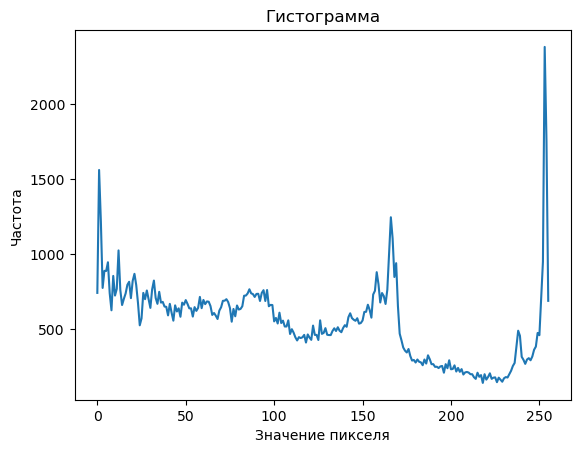

In [29]:
hist = np.zeros(256)

for value in gray.flatten():
    hist[value] += 1

plt.figure()
plt.plot(hist)
plt.title("Гистограмма")
plt.xlabel("Значение пикселя")
plt.ylabel("Частота")

In [30]:
cdf = np.cumsum(hist)
cdf = (cdf - cdf.min())/(cdf.max()-cdf.min()) * 255
cdf = cdf.astype(np.uint8)

equalized = cdf[gray]

Text(0.5, 1.0, 'OpenCV')

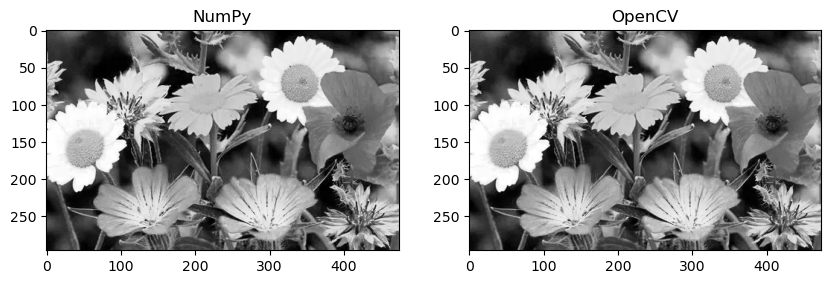

In [31]:
opencv_eq = cv2.equalizeHist(gray)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(equalized, cmap="gray")
plt.title("NumPy")

plt.subplot(1,2,2)
plt.imshow(opencv_eq, cmap="gray")
plt.title("OpenCV")